# Projet Api Immo Lille — Analyse & Modélisation

## 📜 Objectifs du projet

L’objectif de ce projet est d’analyser un jeu de données de transactions immobilières à Lille en 2022,  
afin de comprendre quels facteurs influencent le prix au mètre carré des logements.  

Nous allons :  
- Charger et filtrer les données.  
- Nettoyer et préparer le dataset pour la modélisation.  
- Séparer maisons et appartements pour des analyses distinctes.  
- Construire plusieurs modèles de régression pour prédire le prix au m².  
- Comparer les performances des modèles pour choisir le meilleur.

---

## 1. Chargement des bibliothèques nécessaires

Avant toute chose, nous importons les bibliothèques indispensables pour :  
- Manipuler les données (pandas, numpy).  
- Visualiser les données (matplotlib, seaborn).  
- Construire, évaluer et optimiser les modèles (scikit-learn, xgboost).  
- Sauvegarder les modèles entraînés (joblib).

In [1]:
#import utile pour le projet machine learning 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.compose import ColumnTransformer

import os 

## 2. Chargement et filtrage initial des données

Nous chargeons ici le fichier CSV contenant les transactions.  

Pour garder une analyse ciblée et homogène,  
nous ne conservons que les logements ayant exactement 4 pièces principales.  

Nous sélectionnons aussi les colonnes pertinentes pour notre étude :  
surface bâtie, type de logement, surface du terrain, nombre de lots, et valeur foncière.


In [2]:
df = pd.read_csv("../data/lille_2022.csv")

# Ne garder que les logements à 4 pièces
df = df[df["Nombre pieces principales"] == 4]

# Sélection des colonnes utiles
cols = [
    "Surface reelle bati",
    "Nombre pieces principales",
    "Type local",
    "Surface terrain",
    "Nombre de lots",
    "Valeur fonciere",
]
df = df[cols]
display(df)


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
23,92.0,4.0,Appartement,NaN,1,367000.0
26,70.0,4.0,Appartement,NaN,2,170000.0
58,105.0,4.0,Appartement,NaN,2,355300.0
62,120.0,4.0,Appartement,NaN,1,472500.0
...,...,...,...,...,...,...
11316,103.0,4.0,Appartement,NaN,2,381500.0
11328,117.0,4.0,Appartement,NaN,2,627000.0
11351,78.0,4.0,Appartement,NaN,1,174000.0
11352,72.0,4.0,Maison,278.0,0,200000.0


## 3. Séparation en maisons et appartements & nettoyage

On divise le dataset en deux sous-ensembles : maisons et appartements,  
car les caractéristiques et comportements de prix peuvent différer.  

Ensuite, on gère les valeurs manquantes, notamment dans la surface terrain :  
- Pour les maisons, on remplace les valeurs manquantes par 0 (absence de terrain).  
- Pour les appartements aussi, la surface terrain est souvent nulle, on fait de même.

Cela évite de perdre trop d’observations tout en gardant la cohérence.


In [3]:
# Séparer maisons et appartements
df_maisons = df[df['Type local'].str.lower().str.contains('maison')].copy()
df_apparts = df[df['Type local'].str.lower().str.contains('appartement')].copy()

# Remplacer les valeurs manquantes dans la surface terrain par 0
median_terrain = df_maisons['Surface terrain'].median()
df_maisons['Surface terrain'] = df_maisons['Surface terrain'].fillna(median_terrain)
df_apparts['Surface terrain'] = df_apparts['Surface terrain'].fillna(0)

print("Maisons:")
display(df_maisons.head())

print("\nAppartements:")
display(df_apparts.head())



Maisons:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
65,64.0,4.0,Maison,127.0,0,226900.0
161,70.0,4.0,Maison,192.0,0,205890.0
168,62.0,4.0,Maison,96.0,0,159500.0
176,72.0,4.0,Maison,135.0,0,259900.0



Appartements:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
23,92.0,4.0,Appartement,0.0,1,367000.0
26,70.0,4.0,Appartement,0.0,2,170000.0
58,105.0,4.0,Appartement,0.0,2,355300.0
62,120.0,4.0,Appartement,0.0,1,472500.0
113,71.0,4.0,Appartement,0.0,1,229900.0


In [4]:
print("Maisons:")
display(df_maisons)

print("\nAppartements:")
display(df_apparts)

Maisons:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
18,165.0,4.0,Maison,121.0,0,305000.0
65,64.0,4.0,Maison,127.0,0,226900.0
161,70.0,4.0,Maison,192.0,0,205890.0
168,62.0,4.0,Maison,96.0,0,159500.0
176,72.0,4.0,Maison,135.0,0,259900.0
...,...,...,...,...,...,...
11091,120.0,4.0,Maison,100.0,0,320000.0
11129,110.0,4.0,Maison,225.0,0,412000.0
11235,86.0,4.0,Maison,171.0,0,230000.0
11352,72.0,4.0,Maison,278.0,0,200000.0



Appartements:


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere
23,92.0,4.0,Appartement,0.0,1,367000.0
26,70.0,4.0,Appartement,0.0,2,170000.0
58,105.0,4.0,Appartement,0.0,2,355300.0
62,120.0,4.0,Appartement,0.0,1,472500.0
113,71.0,4.0,Appartement,0.0,1,229900.0
...,...,...,...,...,...,...
11267,112.0,4.0,Appartement,0.0,2,500000.0
11271,81.0,4.0,Appartement,0.0,1,173250.0
11316,103.0,4.0,Appartement,0.0,2,381500.0
11328,117.0,4.0,Appartement,0.0,2,627000.0


## 4. Vérification des valeurs manquantes et des zéros

Il est important de vérifier la présence de données manquantes ou aberrantes (zéros)  
dans les colonnes numériques, car cela peut fausser les modèles.

Cette fonction affiche, pour chaque colonne numérique, le nombre de valeurs nulles et de zéros.


In [5]:
def detect_nan_and_zeros(df: pd.DataFrame) -> pd.DataFrame:
    num_cols = df.select_dtypes(include='number').columns
    results = []
    for col in num_cols:
        n_nan = df[col].isna().sum()
        n_zero = (df[col] == 0).sum()
        results.append({"column": col, "n_nan": n_nan, "n_zero": n_zero})
    return pd.DataFrame(results)

print("Maisons:")
display(detect_nan_and_zeros(df_maisons))

print("\nAppartements:")
display(detect_nan_and_zeros(df_apparts))


Maisons:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,0
3,Nombre de lots,0,340
4,Valeur fonciere,0,0



Appartements:


,column,n_nan,n_zero
0,Surface reelle bati,0,0
1,Nombre pieces principales,0,0
2,Surface terrain,0,386
3,Nombre de lots,0,49
4,Valeur fonciere,0,0


## 5. Calcul du prix au m²

Pour mieux comparer les biens immobiliers, on calcule le prix au mètre carré  
en divisant la valeur foncière par la surface bâtie réelle.

Cette variable cible (`prix_m2`) sera prédite par nos modèles.
 prix au m²

In [6]:
df_maisons['prix_m2'] = df_maisons['Valeur fonciere'] / df_maisons['Surface reelle bati']
df_apparts['prix_m2'] = df_apparts['Valeur fonciere'] / df_apparts['Surface reelle bati']


## 6. Analyse exploratoire : distribution et détection des valeurs aberrantes

Avant de modéliser, on visualise la distribution du prix au m²,  
avec des boxplots pour détecter les valeurs extrêmes (outliers).

On trace également les histogrammes avec estimation de densité (KDE)  
pour observer la répartition du prix au m² dans chaque catégorie.


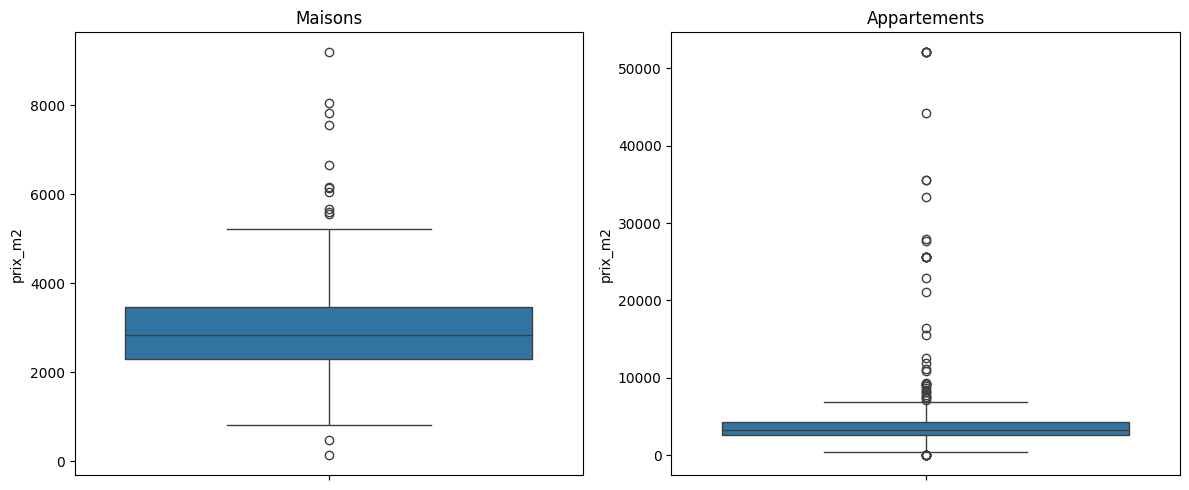

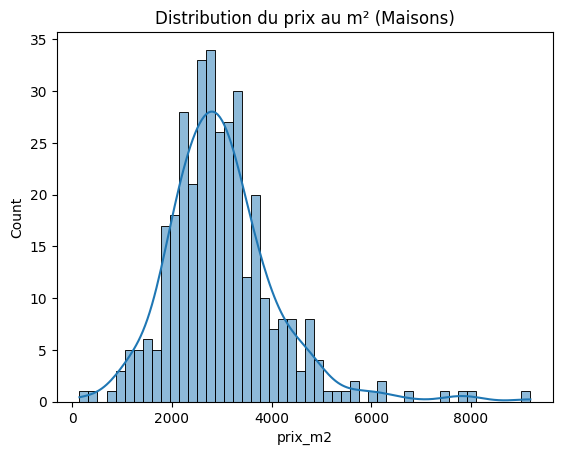

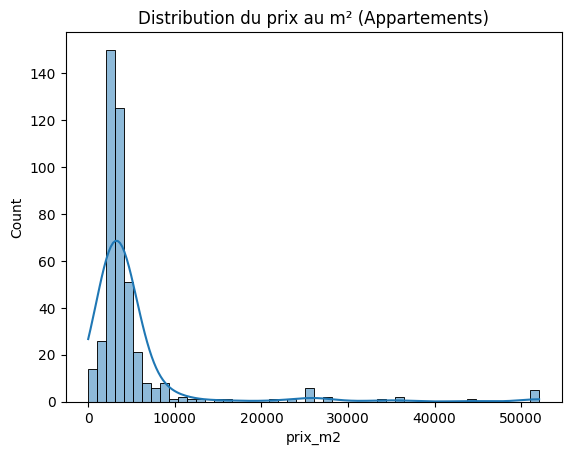

In [7]:
# Boxplots prix/m2
fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.boxplot(data=df_maisons, y='prix_m2', ax=ax[0]).set_title('Maisons')
sns.boxplot(data=df_apparts, y='prix_m2', ax=ax[1]).set_title('Appartements')
plt.tight_layout()
plt.show()

# Distribution
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Maisons)')
plt.show()

sns.histplot(df_apparts['prix_m2'], bins=50, kde=True)
plt.title('Distribution du prix au m² (Appartements)')
plt.show()

## 7. Détection et suppression des valeurs aberrantes

Les outliers peuvent fortement dégrader la qualité des modèles.

On utilise la règle classique de l’IQR (Interquartile Range) pour détecter  
et exclure les valeurs extrêmes dans plusieurs variables clés.

Cette étape garantit que les données sont plus homogènes et fiables.


In [8]:
def detect_outliers(df, column):
    Q1, Q3 = df[column].quantile(0.25), df[column].quantile(0.75)
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    return lb, ub

# Nettoyage pour les maisons
for col in ['prix_m2', 'Surface reelle bati', 'Surface terrain']:
    lb, ub = detect_outliers(df_maisons, col)
    df_maisons = df_maisons[(df_maisons[col] >= lb) & (df_maisons[col] <= ub)]

# Nettoyage pour les appartements
for col in ['prix_m2', 'Surface reelle bati']:
    lb, ub = detect_outliers(df_apparts, col)
    df_apparts = df_apparts[(df_apparts[col] >= lb) & (df_apparts[col] <= ub)]

## Visualisation post-nettoyage : qualité des données et relations

Après le nettoyage des données, il est important de vérifier la qualité des données nettoyées avec des visualisations adaptées.
Cela nous permet de :

  - Valider que les valeurs aberrantes ont bien été supprimées (boxplots et histogrammes).
  - Observer la distribution des variables cibles après nettoyage.
  - Vérifier les relations entre variables numériques via une heatmap de corrélation.
  - Visualiser la relation entre les valeurs prédites et observées (scatter plot) sera fait plus tard lors de l’évaluation des modèles.

### Visualisations pour les maisons

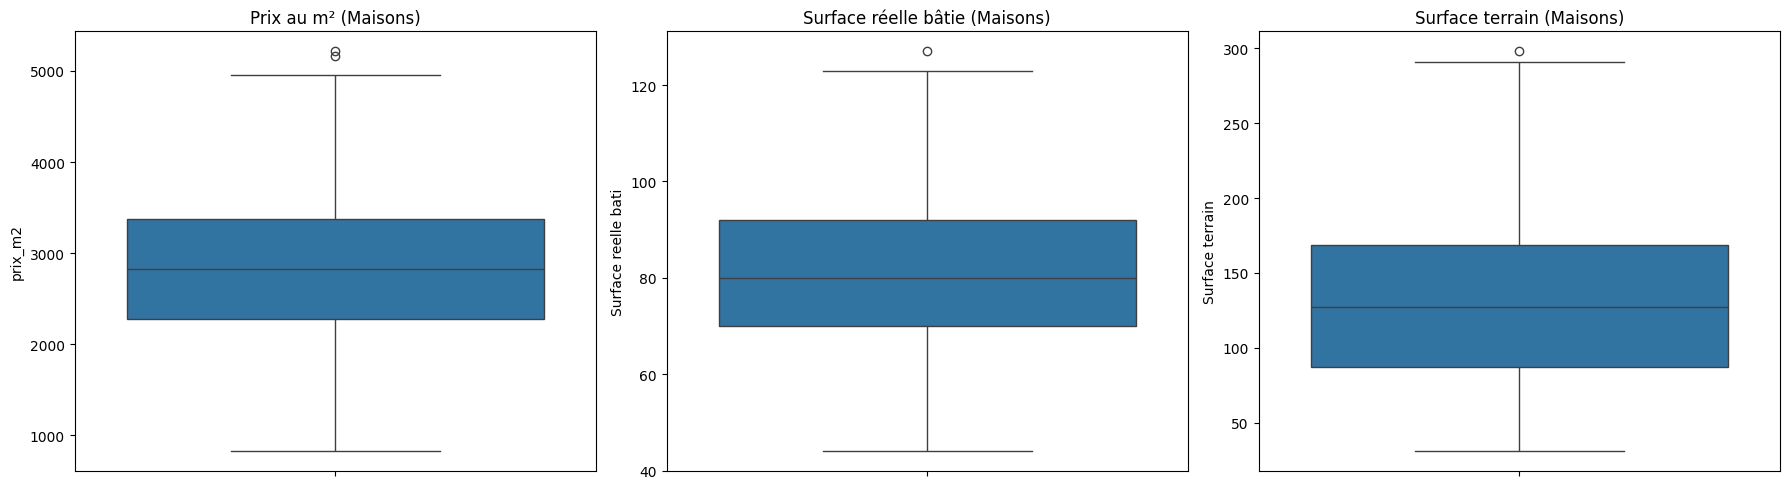

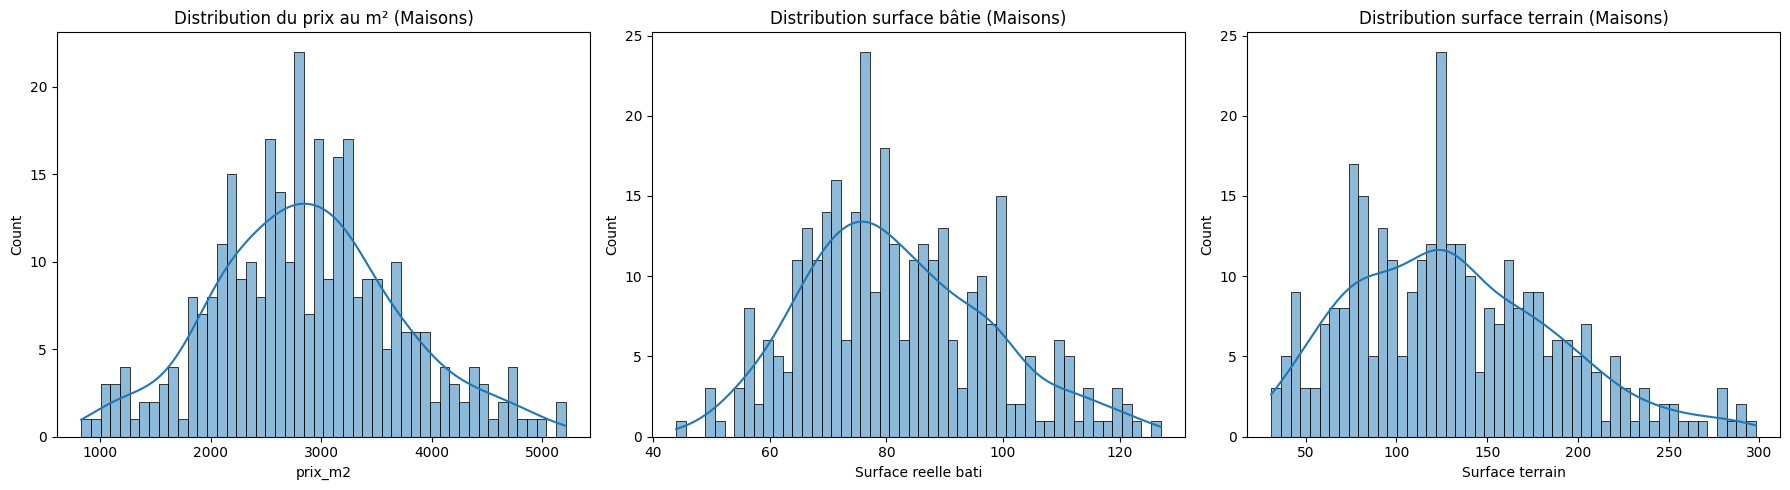

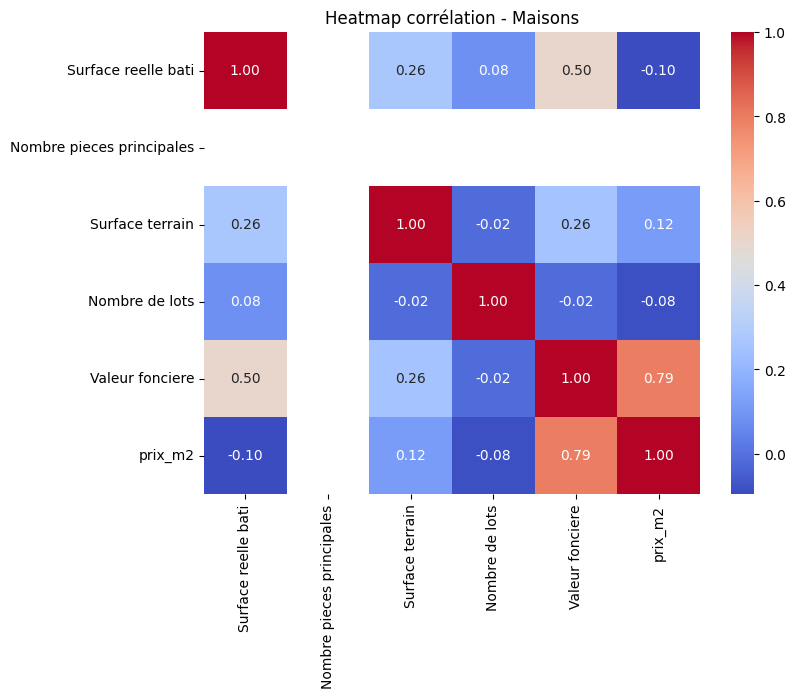

In [9]:
# Boxplots post-nettoyage pour les maisons
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.boxplot(data=df_maisons, y='prix_m2', ax=ax[0]).set_title('Prix au m² (Maisons)')
sns.boxplot(data=df_maisons, y='Surface reelle bati', ax=ax[1]).set_title('Surface réelle bâtie (Maisons)')
sns.boxplot(data=df_maisons, y='Surface terrain', ax=ax[2]).set_title('Surface terrain (Maisons)')
plt.tight_layout()
plt.show()

# Histogrammes post-nettoyage pour les maisons
fig, ax = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(df_maisons['prix_m2'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution du prix au m² (Maisons)')
sns.histplot(df_maisons['Surface reelle bati'], bins=50, kde=True, ax=ax[1])
ax[1].set_title('Distribution surface bâtie (Maisons)')
sns.histplot(df_maisons['Surface terrain'], bins=50, kde=True, ax=ax[2])
ax[2].set_title('Distribution surface terrain (Maisons)')
plt.tight_layout()
plt.show()

# Heatmap de corrélation pour les maisons (seulement colonnes numériques)
plt.figure(figsize=(8,6))
corr_maisons = df_maisons.select_dtypes(include=np.number).corr()
sns.heatmap(corr_maisons, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap corrélation - Maisons')
plt.show()

### Visualisations pour les appartements

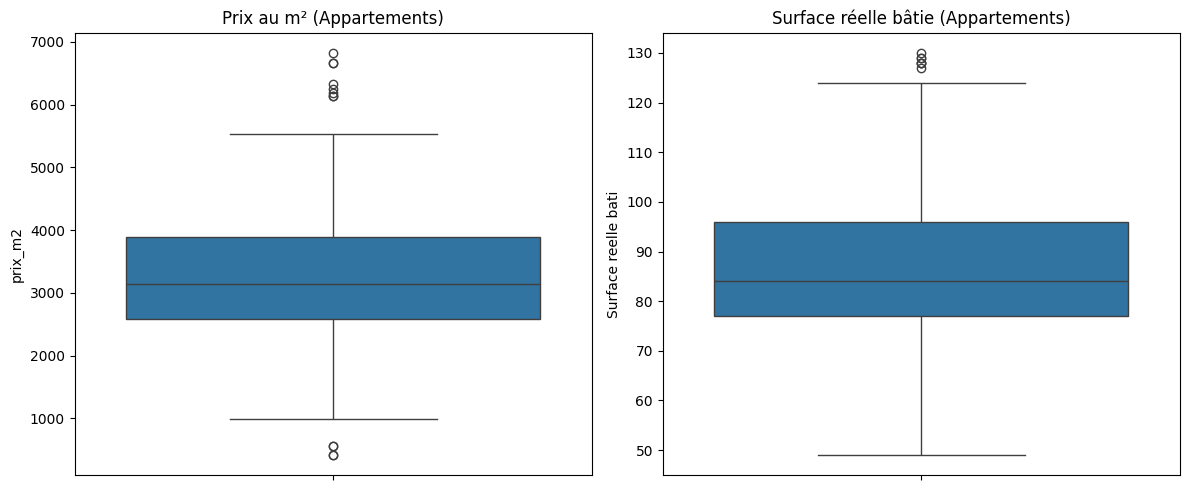

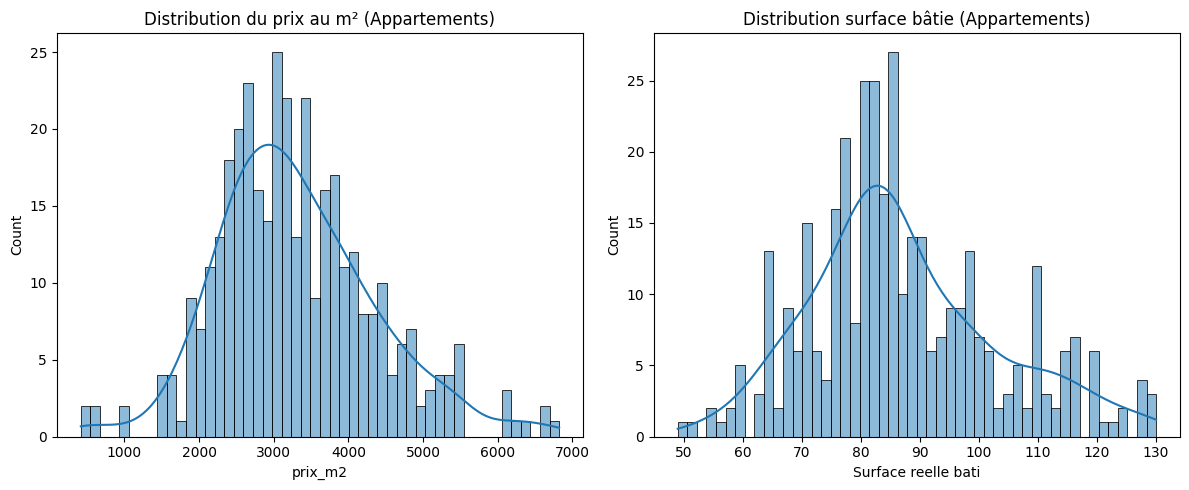

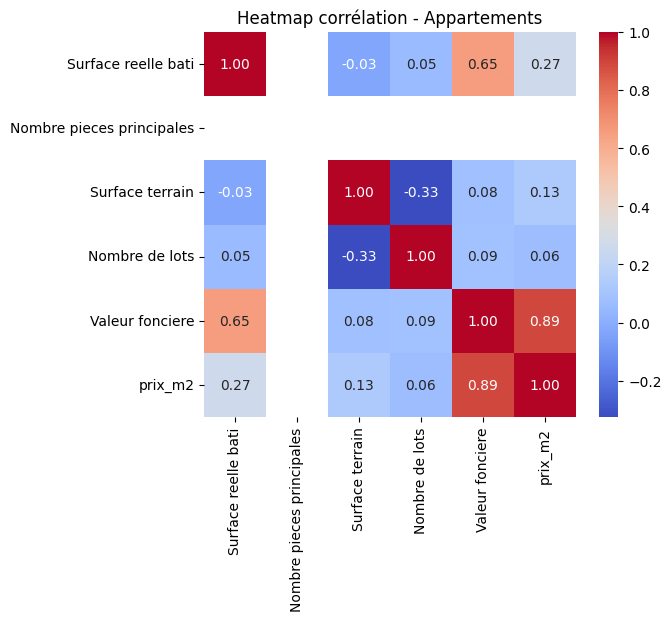

In [10]:
# Boxplots post-nettoyage pour les appartements
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df_apparts, y='prix_m2', ax=ax[0]).set_title('Prix au m² (Appartements)')
sns.boxplot(data=df_apparts, y='Surface reelle bati', ax=ax[1]).set_title('Surface réelle bâtie (Appartements)')
plt.tight_layout()
plt.show()

# Histogrammes post-nettoyage pour les appartements
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df_apparts['prix_m2'], bins=50, kde=True, ax=ax[0])
ax[0].set_title('Distribution du prix au m² (Appartements)')
sns.histplot(df_apparts['Surface reelle bati'], bins=50, kde=True, ax=ax[1])
ax[1].set_title('Distribution surface bâtie (Appartements)')
plt.tight_layout()
plt.show()

# Heatmap de corrélation pour les appartements (colonnes numériques uniquement)
plt.figure(figsize=(6,5))
corr_apparts = df_apparts.select_dtypes(include=np.number).corr()
sns.heatmap(corr_apparts, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Heatmap corrélation - Appartements')
plt.show()

In [11]:
display(df_maisons)
display(df_apparts)

,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
65,64.0,4.0,Maison,127.0,0,226900.0,3545.312500
161,70.0,4.0,Maison,192.0,0,205890.0,2941.285714
168,62.0,4.0,Maison,96.0,0,159500.0,2572.580645
176,72.0,4.0,Maison,135.0,0,259900.0,3609.722222
231,80.0,4.0,Maison,182.0,0,220000.0,2750.000000
...,...,...,...,...,...,...,...
11091,120.0,4.0,Maison,100.0,0,320000.0,2666.666667
11129,110.0,4.0,Maison,225.0,0,412000.0,3745.454545
11235,86.0,4.0,Maison,171.0,0,230000.0,2674.418605
11352,72.0,4.0,Maison,278.0,0,200000.0,2777.777778


,Surface reelle bati,Nombre pieces principales,Type local,Surface terrain,Nombre de lots,Valeur fonciere,prix_m2
23,92.0,4.0,Appartement,0.0,1,367000.0,3989.130435
26,70.0,4.0,Appartement,0.0,2,170000.0,2428.571429
58,105.0,4.0,Appartement,0.0,2,355300.0,3383.809524
62,120.0,4.0,Appartement,0.0,1,472500.0,3937.500000
113,71.0,4.0,Appartement,0.0,1,229900.0,3238.028169
...,...,...,...,...,...,...,...
11267,112.0,4.0,Appartement,0.0,2,500000.0,4464.285714
11271,81.0,4.0,Appartement,0.0,1,173250.0,2138.888889
11316,103.0,4.0,Appartement,0.0,2,381500.0,3703.883495
11328,117.0,4.0,Appartement,0.0,2,627000.0,5358.974359


## 9. Fonction d’entraînement et d’évaluation des modèles

Cette fonction réalise :  
- La préparation des données (scaling, encodage).  
- La séparation train/test.  
- L’entraînement de plusieurs modèles : Decision Tree, Random Forest, XGBoost, et une régression linéaire avec sélection de features.  
- L’évaluation avec plusieurs métriques : MSE (erreur quadratique moyenne), MAE (erreur absolue moyenne) et R².  
- La comparaison graphique des performances.
- le renvoie des resultats pour plus tard et le renovie de smeilleurs pipelines pour réaliser une sauvegarde des models 
- 
On utilise GridSearchCV pour trouver les meilleurs hyperparamètres par validation croisée.


In [12]:
def run_all_models(df, feature_param, target, title="Comparaison des modèles"):
    features = feature_param
    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    preprocessor = ColumnTransformer(
        transformers=[("num", StandardScaler(), features)]
    )

    cv = KFold(n_splits=5, shuffle=True, random_state=42)

    param_grids = {
        "Decision Tree": {
            "model__max_depth": [3, 5, 7, None],
            "model__min_samples_split": [2, 5, 10],
        },
        "Random Forest": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 7, None],
            "model__max_features": ["sqrt", "log2", None],
        },
        "XGBoost": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1, 0.2],
            "model__subsample": [0.7, 1],
            "model__colsample_bytree": [0.7, 1],
        }
    }

    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(random_state=42),
        "Random Forest": RandomForestRegressor(random_state=42),
        "XGBoost": XGBRegressor(random_state=42, verbosity=0),
    }

    results = {}
    best_pipelines = {}

    for name, model in models.items():
        pipe = Pipeline([("preprocessing", preprocessor), ("model", model)])

        if name in param_grids:
            grid = GridSearchCV(
                pipe,
                param_grids[name],
                cv=cv,
                scoring="neg_mean_squared_error",
                n_jobs=-1,
                verbose=1
            )
            grid.fit(X_train, y_train)
            best_model = grid.best_estimator_
        else:
            pipe.fit(X_train, y_train)
            best_model = pipe

        y_pred = best_model.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)

        results[name] = {"MSE": mse, "RMSE": rmse, "MAE": mae, "R2": r2}
        best_pipelines[name] = best_model

        print(f"{name}: MSE={mse:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

    # DataFrame résultats
    results_df = pd.DataFrame(results).T.reset_index().rename(columns={"index": "Model"})

    # Choix du meilleur modèle selon R2
    best_model_name = results_df.sort_values("R2", ascending=False).iloc[0]["Model"]
    best_model_pipeline = best_pipelines[best_model_name]

    print(f"\n➡️ Meilleur modèle : {best_model_name}")

    # Graphique prédictions vs réel pour le meilleur modèle
    y_pred_best = best_model_pipeline.predict(X_test)
    plt.figure(figsize=(7, 6))
    sns.scatterplot(x=y_test, y=y_pred_best)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    plt.xlabel("Valeurs réelles")
    plt.ylabel("Prédictions")
    plt.title(f"Prédictions vs réel - {best_model_name}")
    plt.show()

    # Feature importances si possible
    if best_model_name in ["Random Forest", "XGBoost", "Decision Tree"]:
        importances = best_model_pipeline.named_steps["model"].feature_importances_
        feat_df = pd.DataFrame({"Feature": features, "Importance": importances}).sort_values(
            by="Importance", ascending=False
        )
        plt.figure(figsize=(8, 5))
        sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")
        plt.title(f"Importances des features - {best_model_name}")
        plt.show()

    return best_model_name, best_model_pipeline, results_df.loc[results_df['Model'] == best_model_name]


## 10. Application de la fonction aux maisons

On lance l’entraînement des modèles sur le dataset des maisons.

Cela donnera une idée de quel modèle est le plus performant pour ce type de logement.

On recupere le best_pipelines pour plus tard. 

### Modèles pour maisons ###
=== Maisons ===
Linear Regression: MSE=769429.6731, RMSE=877.1714, MAE=642.9574, R2=0.0041
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree: MSE=722034.7678, RMSE=849.7263, MAE=612.4127, R2=0.0654
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest: MSE=822112.8013, RMSE=906.7044, MAE=658.8394, R2=-0.0641
Fitting 5 folds for each of 24 candidates, totalling 120 fits


c:\Users\Utilisateur\Documents\projet_python_v2\immoprice_lille_fastapi\.venv\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


XGBoost: MSE=907532.3771, RMSE=952.6449, MAE=734.3964, R2=-0.1747

➡️ Meilleur modèle : Decision Tree


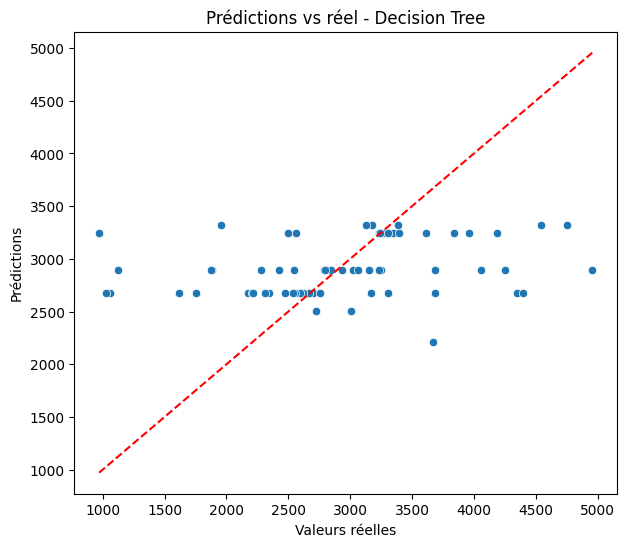

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_6804\1245276068.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


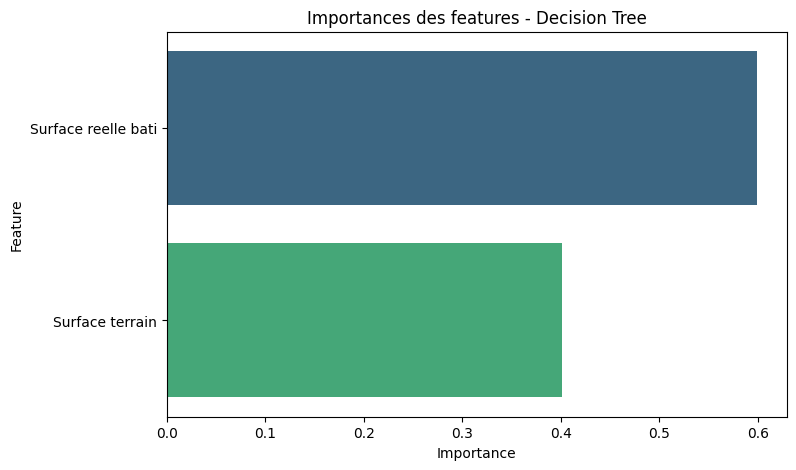

In [ ]:
target = "prix_m2"
feature_maisons= ["Surface reelle bati", "Surface terrain"] 
# Lancement de l'entraînement et sauvegarde pour les maisons
print("### Modèles pour maisons ###")

best_name_maison, best_pipeline_maison, best_result_maison = run_all_models(df_maisons, feature_maisons, target, title="Modèles - Maisons")



## 11. Application de la fonction aux appartements

De même, on entraîne et compare les modèles sur les appartements.

Cette étape permet d’adapter l’approche aux spécificités de ce segment.

On recupere le best_pipelines pour plus tard. 


### Modèles pour appartements ###

=== Appartements ===
Linear Regression: MSE=1294908.8722, RMSE=1137.9406, MAE=849.7644, R2=0.0377
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Decision Tree: MSE=1249169.2909, RMSE=1117.6624, MAE=864.4648, R2=0.0717
Fitting 5 folds for each of 18 candidates, totalling 90 fits
Random Forest: MSE=1205304.6347, RMSE=1097.8637, MAE=842.4602, R2=0.1043
Fitting 5 folds for each of 24 candidates, totalling 120 fits
XGBoost: MSE=1153561.2129, RMSE=1074.0397, MAE=797.1545, R2=0.1427

➡️ Meilleur modèle : XGBoost


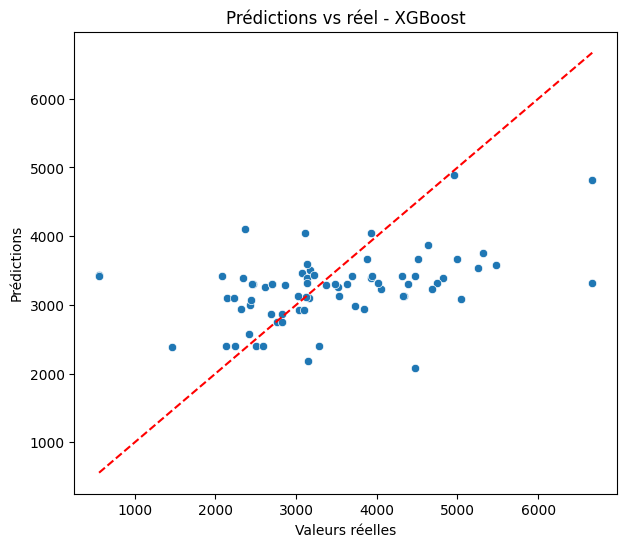

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_6804\1245276068.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x="Importance", y="Feature", palette="viridis")


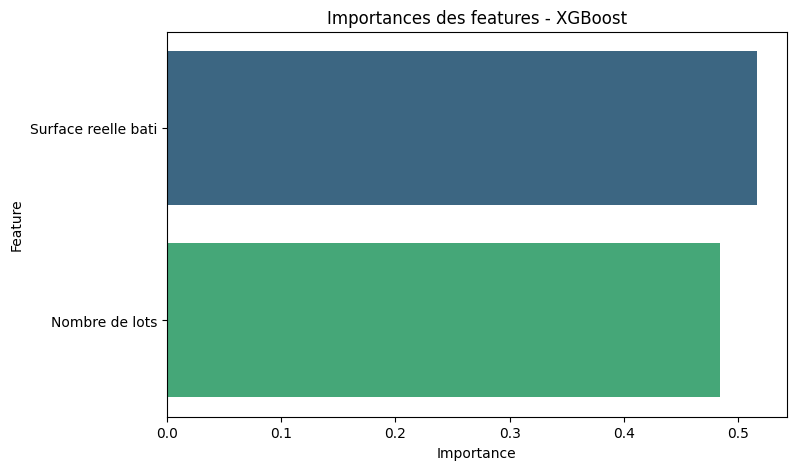

In [ ]:
# Lancement de l'entraînement et sauvegarde pour les appartements
print("\n### Modèles pour appartements ###")
feature_apparts=["Surface reelle bati", "Nombre de lots"] 

best_name_appart, best_pipeline_appart, best_result_appart = run_all_models(df_apparts, feature_apparts, target, title="Modèles - Appartements")



## 12 Fonction d’export des modèles entraînés

Cette fonction `save_models` permet de sauvegarder efficacement plusieurs modèles entraînés dans des fichiers distincts.

### 🔍 Fonctionnement :
- Elle prend en entrée :
  - `best_pipelines` : un dictionnaire où les clés sont les noms des modèles (ex. "Random Forest", "XGBoost") et les valeurs sont les pipelines déjà entraînés.
  - `prefix` : une chaîne de caractères servant de préfixe aux noms des fichiers de sauvegarde.
- Pour chaque modèle :
  - Le nom est transformé (remplacement des espaces par des underscores et des signes `+` par le mot `plus`) pour être compatible avec un nom de fichier.
  - Le pipeline est sauvegardé au format `.pkl` grâce à `joblib`.
  - Un message de confirmation est affiché dans la sortie pour signaler le succès de l’opération.

Cette approche permet de conserver les meilleurs modèles sur disque pour une réutilisation future dans une application ou une nouvelle session d’analyse, sans avoir à réentraîner les modèles à chaque fois.


In [15]:
def save_best_model(best_model_pipeline, model_name, prefix="best_model"):
    os.makedirs("../models", exist_ok=True)
    filename = f"{prefix}_{model_name.replace(' ', '_').lower()}.pkl"
    filepath = os.path.join("../models", filename)
    joblib.dump(best_model_pipeline, filepath)
    print(f"✅ Modèle sauvegardé dans {filepath}")

In [16]:
# Exemple : ton DataFrame
# df = pd.read_csv("ton_fichier.csv")  # À remplacer par ton vrai DataFrame

moyenne_prix_m2_maison = df_maisons["prix_m2"].mean()
mediane_prix_m2_maison = df_maisons["prix_m2"].median()

print(f"Moyenne prix_m2_maison : {moyenne_prix_m2_maison:.2f}")
print(f"Médiane prix_m2_maison : {mediane_prix_m2_maison:.2f}")

# Tu renseignes ici ton MAE obtenu par le modèle
MAE = 612.4127  # à remplacer par le MAE de ton modèle

mape = (MAE / moyenne_prix_m2_maison) * 100
print(f"MAPE_maison = {mape:.2f}%")


Moyenne prix_m2_maison : 2874.62
Médiane prix_m2_maison : 2824.48
MAPE_maison = 21.30%


In [17]:
# Exemple : ton DataFrame
# df = pd.read_csv("ton_fichier.csv")  # À remplacer par ton vrai DataFrame

moyenne_prix_m2_appart = df_apparts["prix_m2"].mean()
mediane_prix_m2_appart = df_apparts["prix_m2"].median()

print(f"Moyenne prix_m2_appart : {moyenne_prix_m2_appart:.2f}")
print(f"Médiane prix_m2_appart : {mediane_prix_m2_appart:.2f}")

# Tu renseignes ici ton MAE obtenu par le modèle
MAE = 797.1545  # à remplacer par le MAE de ton modèle

mape = (MAE / moyenne_prix_m2_appart) * 100
print(f"MAPE_appart = {mape:.2f}%")


Moyenne prix_m2_appart : 3304.16
Médiane prix_m2_appart : 3149.25
MAPE_appart = 24.13%



## 13 Sauvegarde des meilleurs modèles entraînés

Une fois que les modèles pour les maisons et les appartements ont été entraînés et sélectionnés grâce à la fonction `run_all_models`, il est important de les sauvegarder sur le disque pour une utilisation ultérieure (par exemple dans une application de prédiction).

Ici :
- `save_models(best_pipelines_maison, prefix="maisons")` sauvegarde les meilleurs modèles relatifs aux maisons dans des fichiers préfixés par `maisons_...`.
- `save_models(best_pipelines_apparts, prefix="apparts")` sauvegarde les meilleurs modèles relatifs aux appartements dans des fichiers préfixés par `apparts_...`.

Ces fichiers `.pkl` pourront être rechargés facilement dans un autre script grâce à `joblib.load()` sans avoir à réentraîner les modèles à chaque fois.

In [18]:
# Sauvegarde de tous les pipelines dans un seul fichier
#save_all_models_together(best_pipelines_maison, "maisons")

# Sauvegarde de tous les pipelines dans un seul fichier
#save_all_models_together(best_pipelines_maison, "appartements")

# Run pour df_maisons
print("=== Maisons ===")
save_best_model(best_pipeline_maison, best_name_maison, prefix="maison")

# Run pour df_appartements
print("\n=== Appartements ===")
save_best_model(best_pipeline_appart, best_name_appart, prefix="appartement")

=== Maisons ===
✅ Modèle sauvegardé dans ../models\maison_decision_tree.pkl

=== Appartements ===
✅ Modèle sauvegardé dans ../models\appartement_xgboost.pkl
